# 01 · Data Exploration — Valencia DANA 2024

**Author:** Salvador Navas  
**Study area:** Province of Valencia, Spain  
**Event:** DANA of 29 October 2024

---

## Context

On 29 October 2024, a **DANA** (*Depresión Aislada en Niveles Altos*, isolated cold-air trough at
upper levels) triggered catastrophic flash flooding across the Valencia region. The automatic
weather station at **Turís (8337X)** recorded approximately **710 mm in a single day** — an
observation that is, in all likelihood, the highest daily precipitation total ever measured in
mainland Spain and one of the most extreme values ever documented in Western Europe.

The event raises an immediate statistical question: **what is the return period of a 710 mm/day
event, and how does its inclusion in the historical record change our estimates of design
precipitation for various return periods?** This is both a technical question (the statistical
methodology must handle an extreme outlier robustly) and a policy question (design standards
for infrastructure in the region may need to be revised).

---

## What this notebook does

1. **Loads** the daily precipitation series for 9 stations around Turís (AEMET, SIAR, AVAMET networks)
2. **Maps** the station network and summarises metadata
3. **Assesses** temporal coverage and missing-data patterns — critical before frequency analysis
4. **Visualises** the DANA event in the context of each station's full historical record
5. **Exports** clean annual-maxima series for Notebook 02 (statistical analysis)

---

## Station network

Nine stations were selected within a ~50 km radius of Turís, spanning three meteorological
networks with different record lengths and quality controls:

| ID | Station | Network | Notes |
|----|---------|---------|-------|
| **8337X** | **Turís** | **AEMET** | **Maximum DANA recording (~710 mm)** |
| 8309X | Utiel | AEMET | Long AEMET record; inland, higher elevation |
| 8414A | Valencia Airport | AEMET | Long synoptic record; coastal |
| 8416X | Valencia UPV | AEMET | Urban station; shorter record |
| V05 | Cheste | SIAR (MAPAMA) | Agrometeorological network; good 21st-century record |
| V17 | Picassent | SIAR (MAPAMA) | South of Valencia; close to Turís |
| V01 | Pedralba | SIAR (MAPAMA) | Northwest of Valencia |
| c18m111e01 | Chiva | AVAMET | Citizen weather network; dense in time |
| c16m244e01 | Torrent | AVAMET | Urban fringe; short but high-resolution |

> **Why multiple networks?** AEMET stations have the longest records (some since the 1960s)
> but lower spatial density. SIAR and AVAMET stations are more recent but fill spatial gaps
> in the study area. Combining networks maximises the available data for regional analysis.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Resolve repository root ───────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'valencia_dana'
print(f'DATA_ROOT : {DATA_ROOT}')
print(f'Exists    : {DATA_ROOT.exists()}')

---
## 1. Load station metadata and daily series

In [3]:
# Station metadata: lat/lon for mapping
stations_meta = pd.read_csv(DATA_ROOT / 'Estaciones_Conjuntas_V2.csv', index_col=0)
print(f'Total stations in dataset: {len(stations_meta)}')
stations_meta.head(3)

Total stations in dataset: 224


,Latitud,Longitud
V05,39.518889,-0.744167
V23,38.964167,-0.250556
V01,39.566944,-0.717500


In [4]:
# Core stations selected for analysis
STATIONS = ['8337X', '8309X', '8414A', '8416X', 'V05', 'V17', 'V01', 'c18m111e01', 'c16m244e01']

STATION_NAMES = {
    '8337X': 'Turís (AEMET)',       '8309X': 'Utiel (AEMET)',
    '8414A': 'Valencia Airport (AEMET)', '8416X': 'Valencia UPV (AEMET)',
    'V05':   'Cheste (SIAR)',        'V17':   'Picassent (SIAR)',
    'V01':   'Pedralba (SIAR)',
    'c18m111e01': 'Chiva (AVAMET)', 'c16m244e01': 'Torrent (AVAMET)',
}

NETWORK = {
    '8337X': 'AEMET', '8309X': 'AEMET', '8414A': 'AEMET', '8416X': 'AEMET',
    'V05': 'SIAR', 'V17': 'SIAR', 'V01': 'SIAR',
    'c18m111e01': 'AVAMET', 'c16m244e01': 'AVAMET',
}

meta = stations_meta.loc[[s for s in STATIONS if s in stations_meta.index]].copy()
print(f'Stations with metadata: {len(meta)} of {len(STATIONS)}')
meta

Stations with metadata: 7 of 9


,Latitud,Longitud
8337X,39.392231,-0.624717
8416X,39.479737,-0.337495
V05,39.518889,-0.744167
V17,39.362222,-0.497500
V01,39.566944,-0.717500
c18m111e01,39.477800,-0.721100
c16m244e01,39.432506,-0.477892


In [5]:
# Daily precipitation series — large file (~13 MB), ~200 columns
daily_all = pd.read_csv(
    DATA_ROOT / 'Daily_series_conjuntas_V2.csv',
    index_col=0, parse_dates=True
)

avail = [s for s in STATIONS if s in daily_all.columns]
daily = daily_all[avail].copy()

print(f'Period   : {daily.index[0].date()} → {daily.index[-1].date()}')
print(f'Rows     : {len(daily):,}  ({len(daily)/365.25:.0f} calendar years)')
print(f'Stations : {len(avail)} of {len(STATIONS)} found in file')
daily.tail(3)

Period   : 1920-01-01 → 2024-12-10
Rows     : 38,331  (105 calendar years)
Stations : 7 of 9 found in file


,8337X,8416X,V05,V17,V01,c18m111e01,c16m244e01
2024-12-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Station map

The map below shows the geographic distribution of the 9 stations. Key features to notice:

- **Turís (★)** sits at the western edge of the network, in the foothills east of the Iberian
  System where orographic lift amplifies convective precipitation during DANA events.
- The station cluster spans roughly from the coast (Valencia Airport) to ~80 km inland (Utiel),
  capturing the strong precipitation gradient characteristic of Mediterranean Spain.
- SIAR and AVAMET stations fill the area between the AEMET stations, providing spatial continuity
  for the regional frequency analysis in Notebook 02.

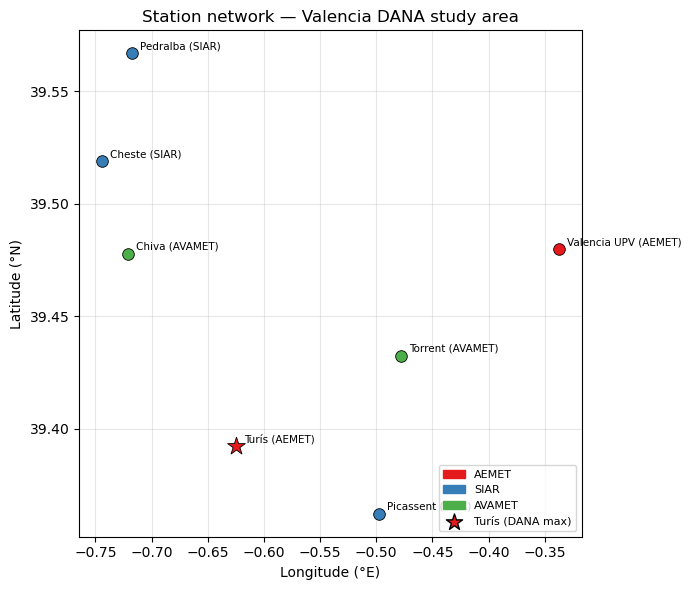

In [6]:
NET_COLORS = {'AEMET': '#e41a1c', 'SIAR': '#377eb8', 'AVAMET': '#4daf4a'}

fig, ax = plt.subplots(figsize=(7, 6))

for st in avail:
    if st not in meta.index:
        continue
    lat = meta.loc[st, 'Latitud']
    lon = meta.loc[st, 'Longitud']
    net = NETWORK.get(st, 'Other')
    color = NET_COLORS.get(net, 'grey')
    is_turis = (st == '8337X')
    ax.scatter(lon, lat, c=color, s=180 if is_turis else 70,
               marker='*' if is_turis else 'o',
               zorder=5, edgecolors='k', linewidths=0.6)
    ax.annotate(STATION_NAMES.get(st, st),
                (lon, lat), textcoords='offset points',
                xytext=(6, 3), fontsize=7.5)

# Legend — networks + Turís marker
handles = [mpatches.Patch(color=c, label=n) for n, c in NET_COLORS.items()]
handles.append(plt.scatter([], [], c='#e41a1c', s=150, marker='*', label='Turís (DANA max)', edgecolors='k'))
ax.legend(handles=handles, fontsize=8, loc='lower right')

ax.set_xlabel('Longitude (°E)', fontsize=10)
ax.set_ylabel('Latitude (°N)', fontsize=10)
ax.set_title('Station network — Valencia DANA study area', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Temporal coverage and data quality

Record length is the single most important factor controlling the uncertainty of extreme-value
estimates. A GEV fit to *n* years of data provides reliable return levels only up to roughly
*n*/2 years (empirical rule of thumb); beyond that, estimates are extrapolations where
parameter uncertainty dominates.

The table below reports:
- **N_years**: effective record length (determines how far we can extrapolate reliably)
- **Missing_%**: fraction of days without a value (gaps cause annual maxima to be `NaN`
  for that year, reducing the effective sample size)
- **Max (mm)**: the highest daily value ever recorded — for most stations, this will be 2024

In [7]:
availability = []
for st in avail:
    s = daily[st].dropna()
    availability.append({
        'Station': STATION_NAMES.get(st, st),
        'First': s.index.min().year if len(s) else np.nan,
        'Last':  s.index.max().year if len(s) else np.nan,
        'N_years': round((s.index.max() - s.index.min()).days / 365.25, 1) if len(s) else np.nan,
        'Missing_%': round(daily[st].isna().mean() * 100, 1),
        'Max (mm)': round(s.max(), 1) if len(s) else np.nan,
    })

avail_df = pd.DataFrame(availability)
print(avail_df.to_string(index=False))

             Station  First  Last  N_years  Missing_%  Max (mm)
       Turís (AEMET)   2008  2024     16.5       85.2     710.8
Valencia UPV (AEMET)   2006  2024     18.7       83.3     130.4
       Cheste (SIAR)   2000  2024     24.8       76.3     201.4
    Picassent (SIAR)   2001  2024     23.7       77.4     196.2
     Pedralba (SIAR)   2000  2024     24.8       76.3     268.0
      Chiva (AVAMET)   2009  2024     15.6       85.8     491.0
    Torrent (AVAMET)   2008  2024     16.0       84.9     128.5


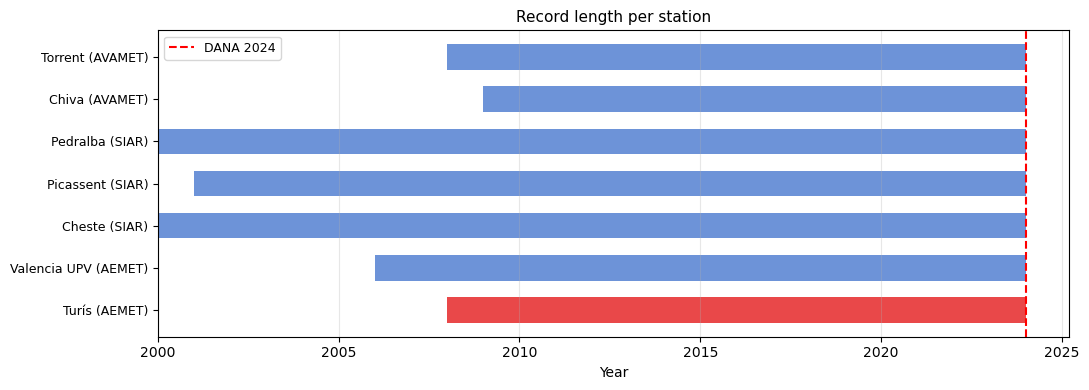

In [8]:
# ── Coverage bar chart ───────────────────────────────────────────────────────
# Each bar spans the active years of that station.
# Red dashed line marks 2024 (DANA year). Short records (AVAMET) limit
# point-frequency analysis but still contribute to regional pooling.
fig, ax = plt.subplots(figsize=(11, 4))

for i, st in enumerate(avail):
    s = daily[st].dropna()
    if len(s) == 0:
        continue
    start = s.index.min().year
    end   = s.index.max().year
    color = '#e41a1c' if st == '8337X' else '#4878cf'
    ax.barh(i, end - start, left=start, height=0.6, color=color, alpha=0.8)

ax.set_yticks(range(len(avail)))
ax.set_yticklabels([STATION_NAMES.get(s, s) for s in avail], fontsize=9)
ax.axvline(2024, color='red', linestyle='--', lw=1.5, label='DANA 2024')
ax.set_xlabel('Year', fontsize=10)
ax.set_title('Record length per station', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Annual maximum daily precipitation (AMS)

### Why use annual block maxima?

The **Annual Maximum Series (AMS)** — one maximum per calendar year — is the standard
input for GEV frequency analysis. The Extreme Value Theorem guarantees that, as the block
size grows, block maxima converge in distribution to one of three extreme-value types
(Gumbel, Fréchet, or Weibull), unified in the GEV family.

**Advantages of AMS:**
- Each observation is approximately independent (different meteorological events)
- The GEV distributional assumption is asymptotically justified
- Standard practice in Spanish hydrology (CAUMAX, MAXPLU databases)

**Limitation:** One maximum per year — potentially discards the 2nd and 3rd largest events
in wet years. For short records (< 20 years) the Peaks Over Threshold (POT / GPD) method
makes better use of the data by retaining all large events. Notebook 02 focuses on GEV/AMS
because the longest stations have > 40 years of data.

**Annual maximum extraction:** `resample('YE').max(min_count=1)` — a year with any missing
days could have a truncated maximum; `min_count=1` ensures years with too many gaps are
marked as `NaN` rather than returning a potentially underestimated value. For daily data,
a common practice is to discard years with > 10% missing days.

In [9]:
# Extract annual maxima — the input for all GEV fitting in Notebook 02
ams = daily.resample('YE').max(min_count=1)
ams.index = ams.index.year
ams.index.name = 'Year'

print(f'AMS shape: {ams.shape}  (years × stations)')
print('\nAnnual maxima — last 5 years:')
print(ams.tail().round(1))

AMS shape: (105, 7)  (years × stations)

Annual maxima — last 5 years:
      8337X  8416X    V05    V17    V01  c18m111e01  c16m244e01
Year                                                           
2020  165.0   54.4  113.4  196.2  101.5       141.6       128.5
2021   56.0   35.1   44.0  107.3   91.1        80.0        52.6
2022   33.8   47.5  102.5   84.6  153.8       123.2       125.2
2023   50.6   41.8   27.7   57.9   36.5        34.2        80.5
2024  710.8   46.0  131.5  118.3  239.9       491.0        19.6


---
## 5. The DANA event in historical context

Placing the 2024 DANA value within the historical record at Turís is essential to
understand the statistical challenge:

- If 710 mm is **only 2–3 times the historical mean annual maximum**, GEV extrapolation
  to that value will be relatively reliable.
- If 710 mm is **5–10 times larger than anything previously recorded**, we are in
  deep extrapolation territory — the GEV shape parameter ξ dominates, and its uncertainty
  translates to very wide confidence intervals on the return period.

The bar chart below reveals which case applies.

In [10]:
turis_ams = ams['8337X'].dropna()
mean_excl = turis_ams.drop(index=2024, errors='ignore').mean()
prev_max  = turis_ams.drop(index=2024, errors='ignore').max()
dana_val  = turis_ams.get(2024, np.nan)

print(f'Turís (8337X):')
print(f'  Record length     : {len(turis_ams)} years')
print(f'  Mean max (excl.)  : {mean_excl:.1f} mm')
print(f'  Previous record   : {prev_max:.1f} mm')
if pd.notna(dana_val):
    print(f'  DANA 2024         : {dana_val:.1f} mm')
    print(f'  Ratio DANA/mean   : {dana_val/mean_excl:.1f}×')
    print(f'  Ratio DANA/prev   : {dana_val/prev_max:.1f}× previous record')

Turís (8337X):
  Record length     : 17 years
  Mean max (excl.)  : 73.8 mm
  Previous record   : 165.0 mm
  DANA 2024         : 710.8 mm
  Ratio DANA/mean   : 9.6×
  Ratio DANA/prev   : 4.3× previous record


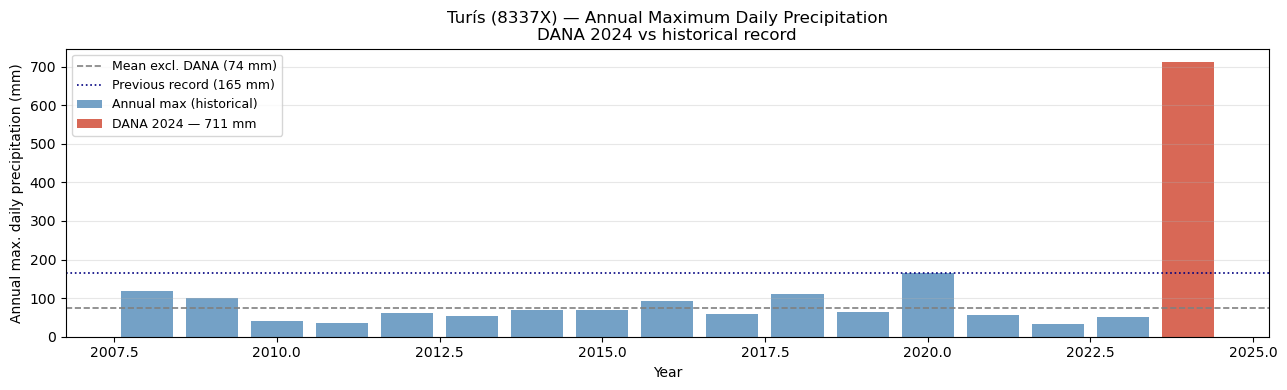

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.bar(turis_ams.drop(index=2024, errors='ignore').index,
       turis_ams.drop(index=2024, errors='ignore').values,
       color='steelblue', alpha=0.75, label='Annual max (historical)')

if pd.notna(dana_val):
    ax.bar([2024], [dana_val], color='#d6604d', alpha=0.95,
           label=f'DANA 2024 — {dana_val:.0f} mm')

ax.axhline(mean_excl, color='grey', linestyle='--', lw=1.2,
           label=f'Mean excl. DANA ({mean_excl:.0f} mm)')
ax.axhline(prev_max, color='navy', linestyle=':', lw=1.2,
           label=f'Previous record ({prev_max:.0f} mm)')

ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Annual max. daily precipitation (mm)', fontsize=10)
ax.set_title('Turís (8337X) — Annual Maximum Daily Precipitation\nDANA 2024 vs historical record',
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# What did each station record during the DANA episode?
# A 3-day window around 29 Oct 2024 captures both the main pulse and any spillover.
dana_window = daily.loc['2024-10-27':'2024-10-31']

print('Precipitation during DANA episode (27–31 Oct 2024):')
print(f'{"Station":<30} {"Day max (mm)":>14} {"3-day total (mm)":>18}')
print('-' * 65)
for st in avail:
    name = STATION_NAMES.get(st, st)
    day_max   = dana_window[st].max()
    three_day = dana_window[st].sum(min_count=1)
    print(f'{name:<30} {day_max:>14.1f} {three_day:>18.1f}')

Precipitation during DANA episode (27–31 Oct 2024):
Station                          Day max (mm)   3-day total (mm)
-----------------------------------------------------------------
Turís (AEMET)                           710.8              780.2
Valencia UPV (AEMET)                     22.1               23.5
Cheste (SIAR)                           131.5              160.4
Picassent (SIAR)                        118.3              127.2
Pedralba (SIAR)                         239.9              270.1
Chiva (AVAMET)                          491.0              501.6
Torrent (AVAMET)                          7.6               19.1


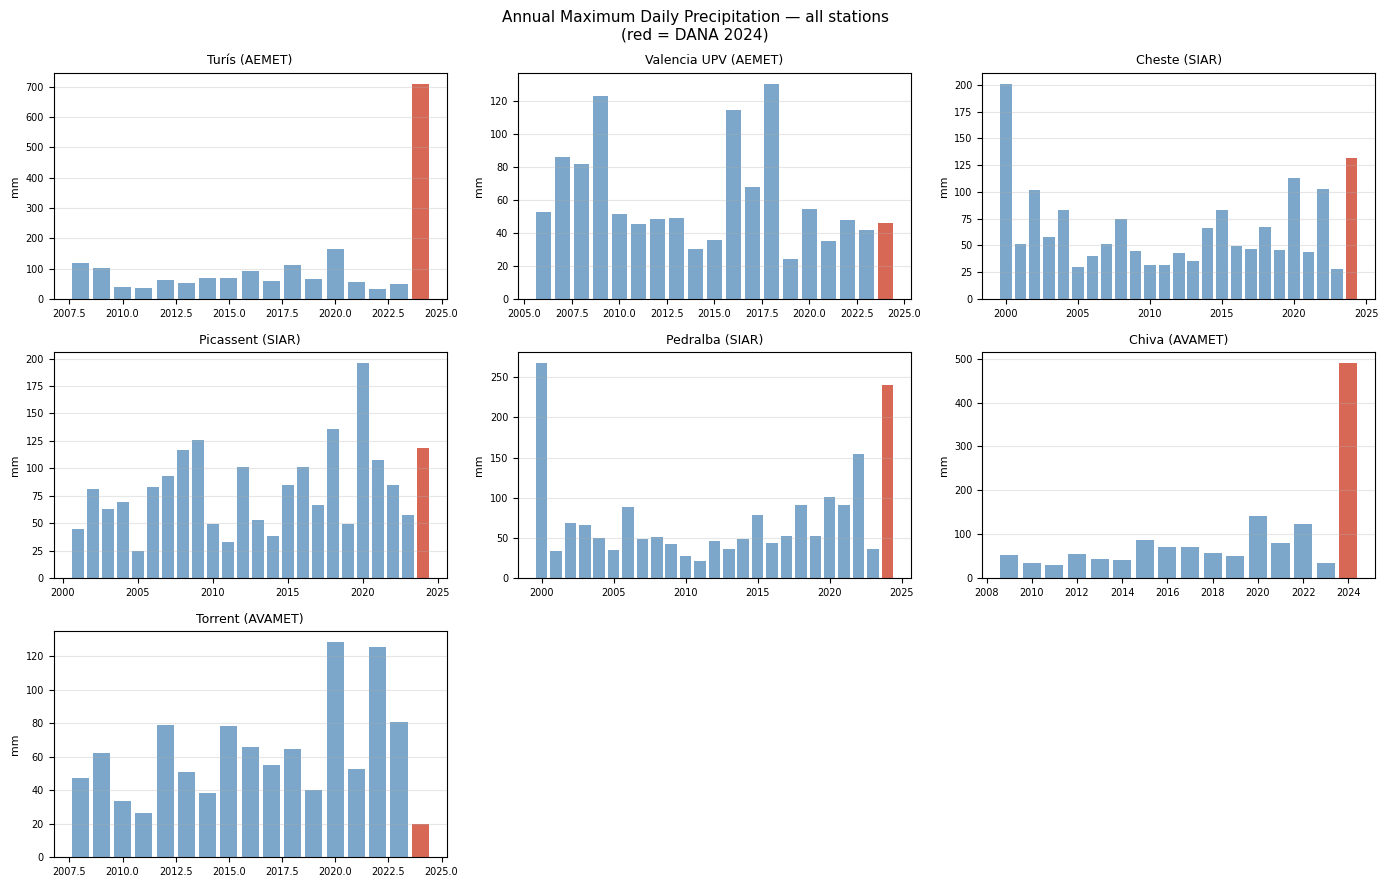

In [13]:
# ── Multi-station AMS overview ───────────────────────────────────────────────
# Comparing the DANA bar across all stations shows the spatial extent of the event:
# stations close to Turís also recorded historically unprecedented values,
# while more distant stations (Valencia Airport, Utiel) show less extreme anomalies.
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=False)
axes = axes.flatten()

for i, st in enumerate(avail[:9]):
    ax = axes[i]
    s  = ams[st].dropna()
    ax.bar(s.drop(index=2024, errors='ignore').index,
           s.drop(index=2024, errors='ignore').values,
           color='steelblue', alpha=0.7)
    if 2024 in s.index:
        ax.bar([2024], [s[2024]], color='#d6604d', alpha=0.95)
    ax.set_title(STATION_NAMES.get(st, st), fontsize=9)
    ax.set_ylabel('mm', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Annual Maximum Daily Precipitation — all stations\n(red = DANA 2024)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. Export annual maxima

The annual-maxima table is saved as a CSV for direct use in Notebook 02. This avoids
re-reading the large daily file and makes the analysis pipeline modular: any changes
to station selection or quality-control thresholds only require re-running this notebook.

In [14]:
out_path = SESSION_DATA_ROOT / 'annual_maxima.csv'
ams.to_csv(out_path)

# Summary of what was written
n_valid = {st: ams[st].notna().sum() for st in avail}
print(f'Saved: {out_path}')
print(f'Shape: {ams.shape}  (years × stations)\n')
print('Valid annual maxima per station (NaN years excluded from GEV fit):')
for st, n in n_valid.items():
    print(f'  {STATION_NAMES.get(st, st):30s}: {n} years')

Saved: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/annual_maxima.csv
Shape: (105, 7)  (years × stations)

Valid annual maxima per station (NaN years excluded from GEV fit):
  Turís (AEMET)                 : 17 years
  Valencia UPV (AEMET)          : 19 years
  Cheste (SIAR)                 : 25 years
  Picassent (SIAR)              : 24 years
  Pedralba (SIAR)               : 25 years
  Chiva (AVAMET)                : 16 years
  Torrent (AVAMET)              : 17 years
